## Adatok betöltése

In [400]:
import pandas as pd

In [401]:
train = pd.read_csv('./titanic/train.csv')
test = pd.read_csv('./titanic/test.csv')

In [402]:
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [403]:
print(train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## Hiányzó és kiugró értékek kezelése

In [404]:
import seaborn as sb
import matplotlib.pyplot as plt

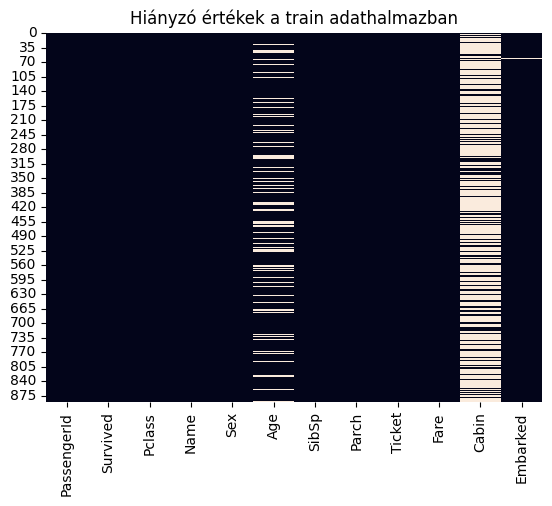

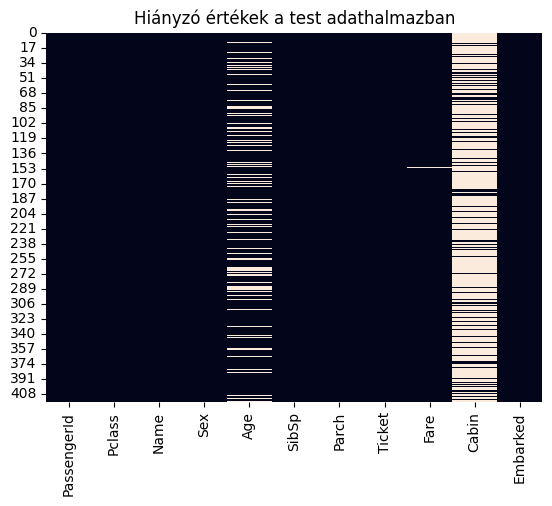

In [405]:
sb.heatmap(train.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train adathalmazban')
plt.show()

sb.heatmap(test.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a test adathalmazban')
plt.show()

In [406]:
train_new = train.copy()

train_new['Age'] = train_new['Age'].fillna(train_new['Age'].median())

embarked_mode = train_new['Embarked'].mode()[0]
train_new['Embarked'] = train_new['Embarked'].fillna(embarked_mode)

train_new = train_new.drop(columns=['Cabin'])
train_new = train_new.drop(columns=['PassengerId'])
train_new = train_new.drop(columns=['Ticket'])

In [407]:
test_new = test.copy()

test_new['Age'] = test_new['Age'].fillna(train_new['Age'].median())
test_new['Fare'] = test_new['Fare'].fillna(train_new['Fare'].median())

test_new['Embarked'] = test_new['Embarked'].fillna(embarked_mode)

test_new = test_new.drop(columns=['Cabin'])
test_new = test_new.drop(columns=['PassengerId'])
test_new = test_new.drop(columns=['Ticket'])

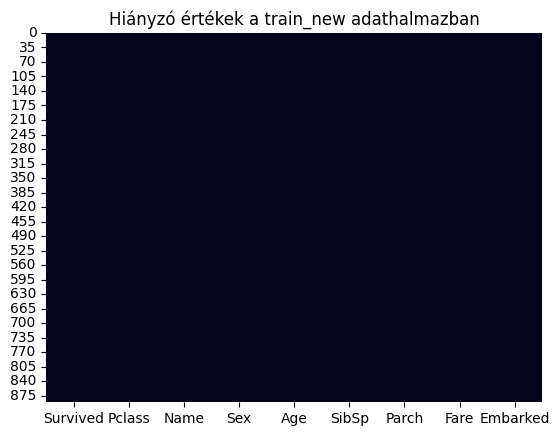

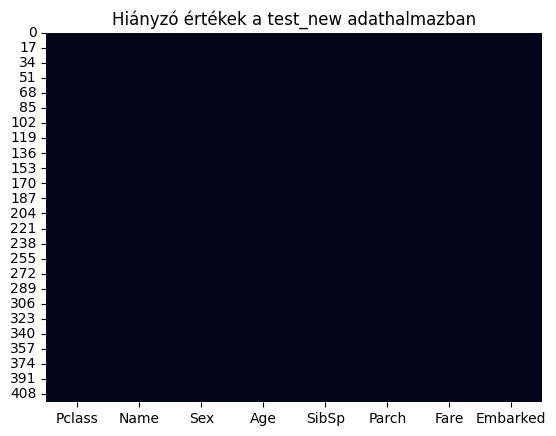

In [408]:
sb.heatmap(train_new.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train_new adathalmazban')
plt.show()

sb.heatmap(test_new.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a test_new adathalmazban')
plt.show()

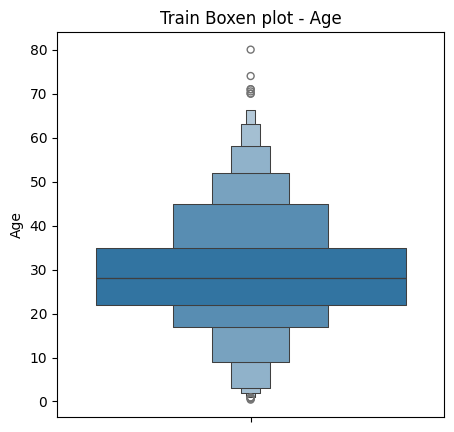

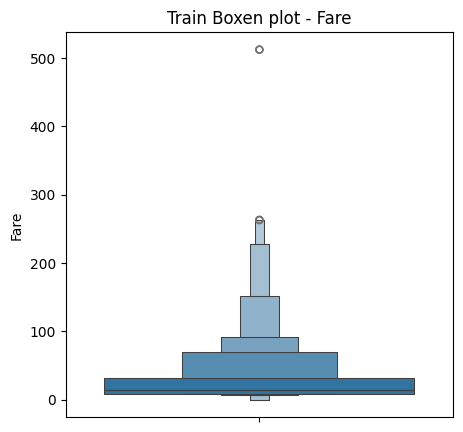

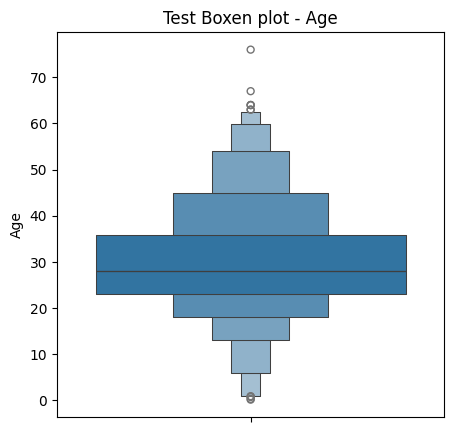

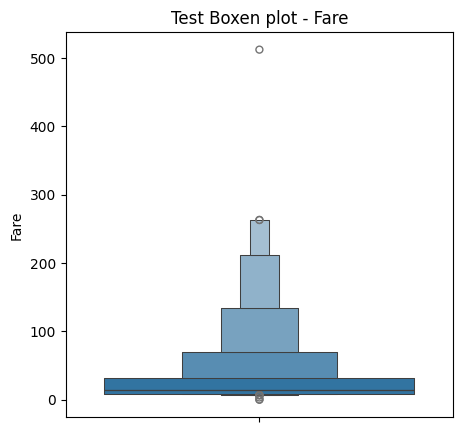

In [409]:
for col in ['Age', 'Fare']:
    plt.figure(figsize=(5,5))
    sb.boxenplot(y=train_new[col])
    plt.title(f'Train Boxen plot - {col}')
    plt.show()

for col in ['Age', 'Fare']:
    plt.figure(figsize=(5,5))
    sb.boxenplot(y=test_new[col])
    plt.title(f'Test Boxen plot - {col}')
    plt.show()

## Feature engineering

In [410]:
train_new['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test_new['FamilySize'] = train['SibSp'] + train['Parch'] + 1

In [411]:
train_new['IsAlone'] = (train_new['FamilySize'] == 1).astype(int)
test_new['IsAlone'] = (test_new['FamilySize'] == 1).astype(int)

In [412]:
train_new['Title'] = train_new['Name'].str.extract(r', (\w+)\.')[0]
test_new['Title'] = test_new['Name'].str.extract(r', (\w+)\.')[0]

title_counts = train_new['Title'].value_counts()
rare_titles = title_counts[title_counts < 30].index

train_new['Title'] = train_new['Title'].replace(rare_titles, 'Rare')
test_new['Title'] = test_new['Title'].replace(rare_titles, 'Rare')

train_new = pd.get_dummies(train_new, columns=['Title'], drop_first=False, dtype=int)
test_new = pd.get_dummies(test_new, columns=['Title'], drop_first=False, dtype=int)

train_new = train_new.drop(columns=['Name'])
test_new = test_new.drop(columns=['Name'])

In [413]:
train_new = pd.get_dummies(train_new, columns=['Embarked'], drop_first=False, dtype=int)
test_new = pd.get_dummies(test_new, columns=['Embarked'], drop_first=False, dtype=int)

In [414]:
train_new['Sex'] = train_new['Sex'].map({'male': 0, 'female': 1})
test_new['Sex'] = test_new['Sex'].map({'male': 0, 'female': 1})

In [415]:
print(train_new.columns)
print(test_new.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'IsAlone', 'Title_Dona', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [416]:
print(train_new.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0         0       3    0  22.0      1      0   7.2500           2        0   
1         1       1    1  38.0      1      0  71.2833           2        0   
2         1       3    1  26.0      0      0   7.9250           1        1   
3         1       1    1  35.0      1      0  53.1000           2        0   
4         0       3    0  35.0      0      0   8.0500           1        1   

   Title_Master  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  Embarked_C  \
0             0           0         1          0           0           0   
1             0           0         0          1           0           1   
2             0           1         0          0           0           0   
3             0           0         0          1           0           0   
4             0           0         1          0           0           0   

   Embarked_Q  Embarked_S  
0           0           1  
1           0     

## Standardizálás

In [417]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
continuous_features = ['Age', 'Fare']

train_new[continuous_features] = scaler.fit_transform(train_new[continuous_features])
test_new[continuous_features] = scaler.transform(test_new[continuous_features])

In [418]:
train_new.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,2,0,0,0,1,0,0,0,0,1
1,1,1,1,0.663861,1,0,0.786845,2,0,0,0,0,1,0,1,0,0
2,1,3,1,-0.258337,0,0,-0.488854,1,1,0,1,0,0,0,0,0,1
3,1,1,1,0.433312,1,0,0.420730,2,0,0,0,0,1,0,0,0,1
4,0,3,0,0.433312,0,0,-0.486337,1,1,0,0,1,0,0,0,0,1


## Adatok szétválasztása

In [419]:
from sklearn.model_selection import train_test_split

In [420]:
x_train = train_new.drop('Survived', axis=1)
y_train = train_new['Survived']

In [421]:
x_train, x_validation, y_train, y_validation = train_test_split(
    x_train, y_train, test_size=0.2, random_state=22, stratify=y_train
) 

In [422]:
x_test = test_new.copy()

## Modell - Neurális háló

In [423]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [424]:
print(x_train.shape)
print(x_train.shape[1])

(712, 16)
16


In [425]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\User\Desktop\X49HPQ_gepitanulas\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [426]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [427]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [428]:
print(x_train.dtypes)

Pclass            int64
Sex               int64
Age             float64
SibSp             int64
Parch             int64
Fare            float64
FamilySize        int64
IsAlone           int64
Title_Master      int64
Title_Miss        int64
Title_Mr          int64
Title_Mrs         int64
Title_Rare        int64
Embarked_C        int64
Embarked_Q        int64
Embarked_S        int64
dtype: object


In [429]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_validation, y_validation),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6699 - loss: 0.5913 - val_accuracy: 0.7542 - val_loss: 0.5340
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7837 - loss: 0.5174 - val_accuracy: 0.7989 - val_loss: 0.4803
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8048 - loss: 0.4786 - val_accuracy: 0.7821 - val_loss: 0.4724
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8118 - loss: 0.4504 - val_accuracy: 0.7989 - val_loss: 0.4644
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8146 - loss: 0.4385 - val_accuracy: 0.8101 - val_loss: 0.4467
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8230 - loss: 0.4296 - val_accuracy: 0.8268 - val_loss: 0.4370
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8244 - loss: 0.4205 - val_accuracy: 0.8045 - val_loss: 0.4418
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8343 - loss: 0.4104 - val_accuracy: 0.8101 - v